# Figure 1

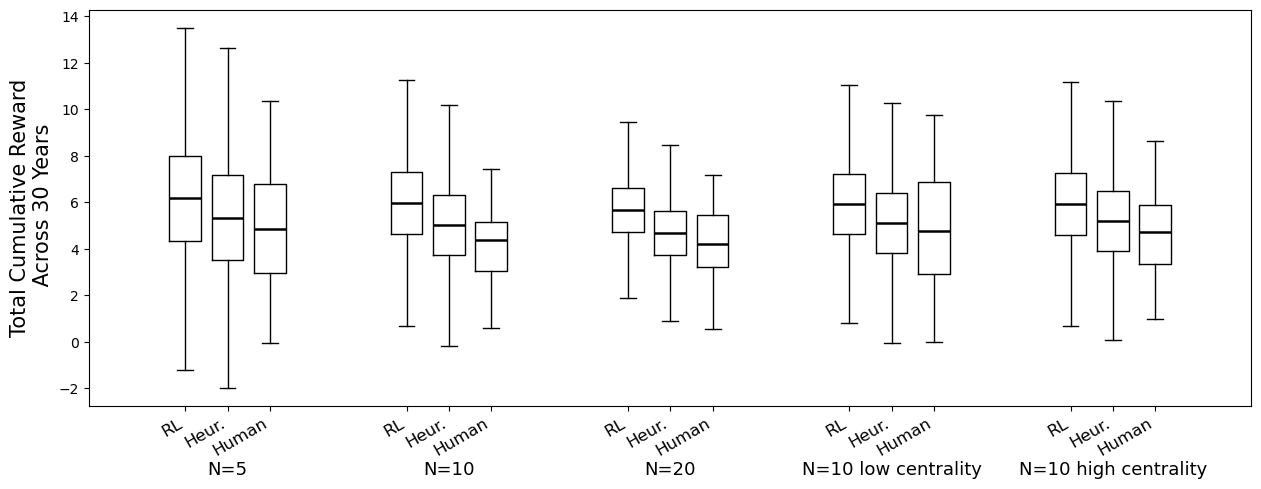

In [ ]:
# check the human and rl performance for n=5,10,20
from call_in_data import *
from avgperformance import *
import matplotlib.pyplot as plt
import pandas as pd
import os 
import scipy.stats as stats
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

total_scores_dict = {}
for n in [18,20,21,22,23]:
    playdf,_ = call_in_data(envid=n)
    total_scores = []
    for i in range(len(playdf)):
        total_scores.append(playdf[i]['total_rewards'])
    total_scores_dict[n] = total_scores
        
# get rl performance for n=18,20,21
n21filename = './human_play_results/RL_performance_summary_seed252358_n21.csv'
n20filename = './human_play_results/RL_performance_summary_seed398845_n20.csv'
n18filename = './human_play_results/RL_performance_summary_seed578396_n18.csv'
n22filename = './human_play_results/RL_performance_summary_seed839394_n22.csv'
n23filename = './human_play_results/RL_performance_summary_seed444253_n23.csv'

# read in the csv files
summaryn18 = pd.read_csv(n18filename)
summaryn20 = pd.read_csv(n20filename)
summaryn21 = pd.read_csv(n21filename)
summaryn22 = pd.read_csv(n22filename)
summaryn23 = pd.read_csv(n23filename)

# first row is summary, get rid 
summaryn18 = summaryn18.iloc[1:]
summaryn20 = summaryn20.iloc[1:]
summaryn21 = summaryn21.iloc[1:]
summaryn22 = summaryn22.iloc[1:]
summaryn23 = summaryn23.iloc[1:]

rl_summary = {
    18: summaryn18['rewards'].astype(float),
    20: summaryn20['rewards'].astype(float),
    21: summaryn21['rewards'].astype(float),
    22: summaryn22['rewards'].astype(float),
    23: summaryn23['rewards'].astype(float),
}

human_summary = {
    18: total_scores_dict[18],
    20: total_scores_dict[20],
    21: total_scores_dict[21],
    22: total_scores_dict[22],
    23: total_scores_dict[23],
}

group_name = {
    18: 'N=5',
    20: 'N=10',
    21: 'N=20',
    22: 'N=10 low centrality',
    23: 'N=10 high centrality',
}
# get heuristics performance 
heurn21filename = './heuristics_play_results/heur_performance_summary_n21.csv'
heurn20filename = './heuristics_play_results/heur_performance_summary_n20.csv'
heurn18filename = './heuristics_play_results/heur_performance_summary_n18.csv'
heurn22filename = './heuristics_play_results/heur_performance_summary_n22.csv'
heurn23filename = './heuristics_play_results/heur_performance_summary_n23.csv'

heuristics_summary = {}
for key, fname in [(18, heurn18filename), (20, heurn20filename), (21, heurn21filename), (22, heurn22filename), (23, heurn23filename)]:
    df_tmp = pd.read_csv(fname).iloc[1:]
    heuristics_summary[key] = df_tmp['rewards'].astype(float)

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

envids = [18, 20, 21, 22, 23]
group_labels = [f"{group_name[n]}" for n in envids]

box_width = 0.22
group_spacing = 1.15
positions_per_group = np.array([0, 1, 2]) * box_width  # RL, Heur, Human
group_centers = np.arange(len(envids)) * group_spacing

fig, ax = plt.subplots(figsize=(15, 6))

all_positions = []
all_type_labels = []

for i, n in enumerate(envids):
    data = [
        rl_summary[n].values,
        heuristics_summary[n].values,
        np.array(human_summary[n], dtype=float),
    ]

    # Place RL/Heur/Human as three boxes within each environment group.
    pos = group_centers[i] + positions_per_group - box_width
    ax.boxplot(
        data,
        positions=pos,
        widths=box_width * 0.75,
        showfliers=False,
        showmeans=True,
        meanline=True,
        meanprops=dict(color='black', linewidth=1.8, linestyle='-'),
        medianprops=dict(color='none', linewidth=0),
    )

    all_positions.extend(pos.tolist())
    all_type_labels.extend(['RL', 'Heur.', 'Human'])

# X-axis: RL/Heur/Human repeated within each group.
ax.set_xticks(all_positions)
ax.set_xticklabels(all_type_labels, fontsize=12, rotation=30, ha='right')

# Add environment group labels under each triplet.
for center, label in zip(group_centers, group_labels):
    ax.text(center, -0.14, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=13)

ax.set_ylabel('Total Cumulative Reward\n Across 30 Years', fontsize=15)

plt.subplots_adjust(bottom=0.22)
plt.show()


# Figure 2

10


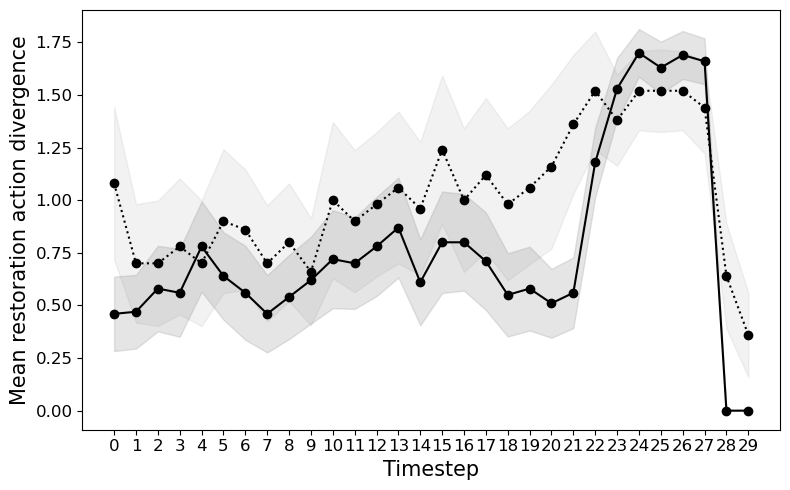

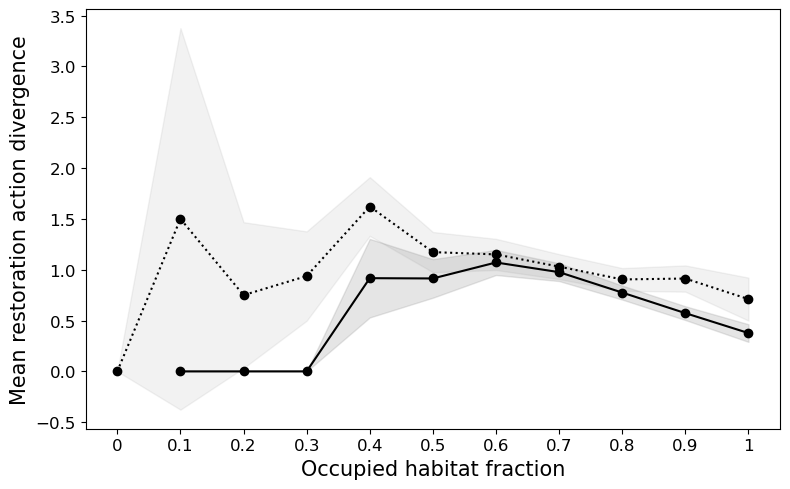

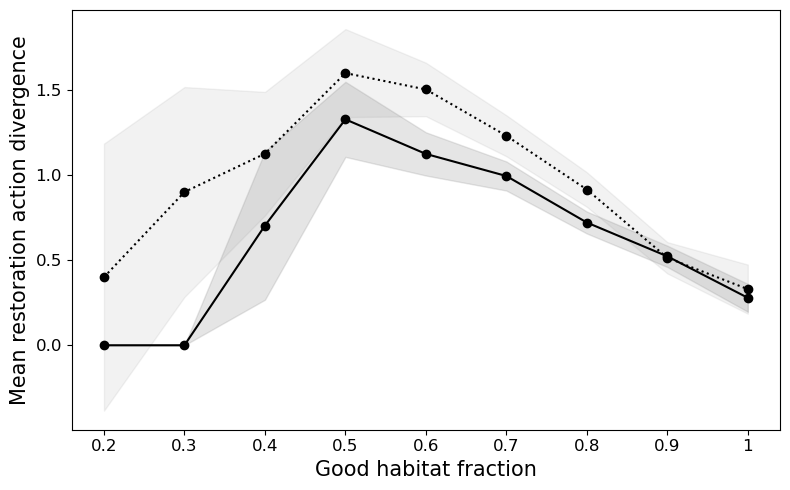

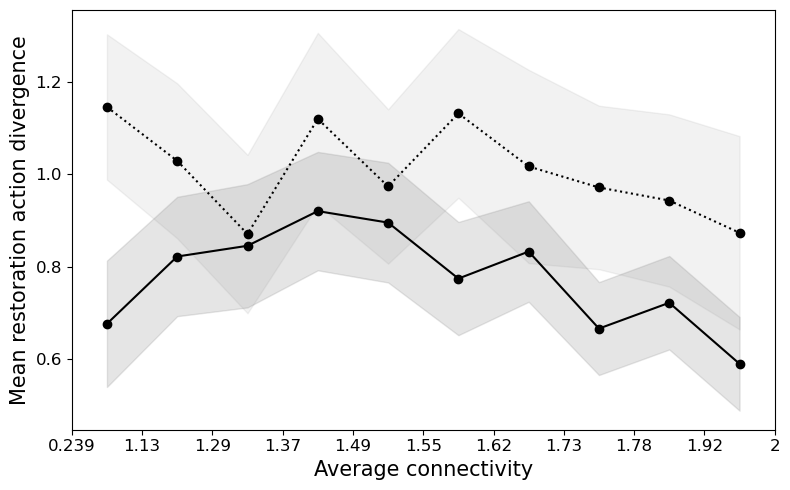

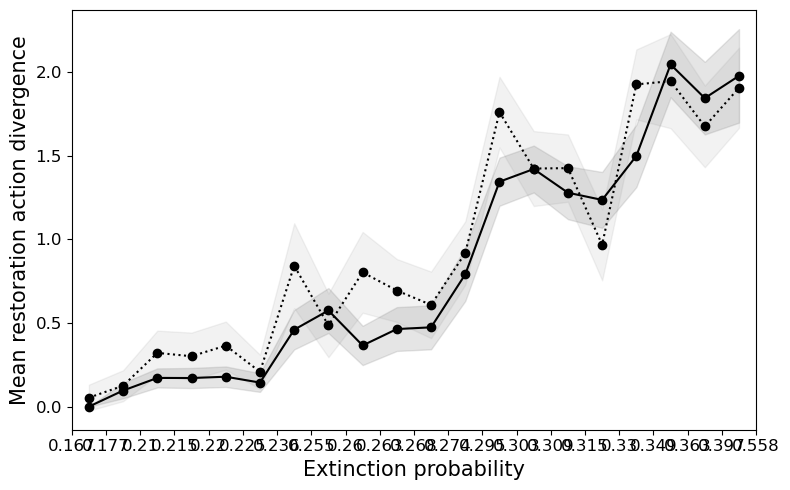

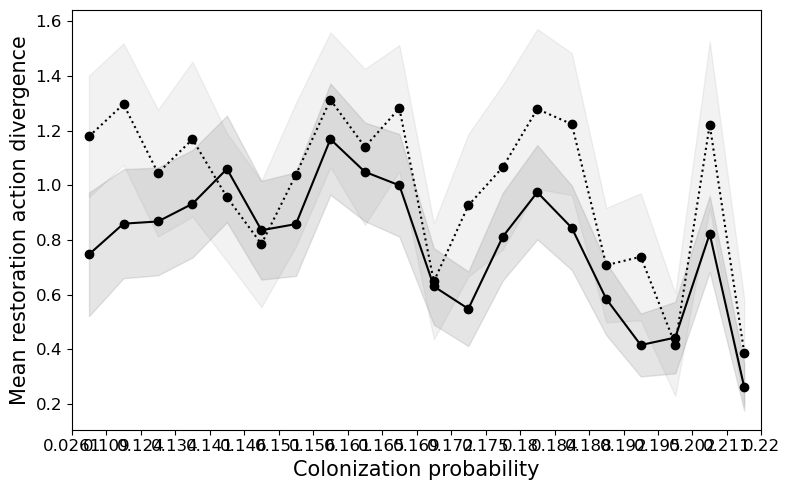

In [50]:
# restoration action distance analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

###################################################
envid = 20 # 18= n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
legend_on = 0 # if 1, show legend/title; if 0, hide both.
# only use 20. we specifically got more samples for step-scale analysis.
###################################################

# Heuristic play data
heur_playdf, _ = call_in_heuristic_data(envid=envid, with_valdiff=True, merge=True)
patchnum = heur_playdf['observations'][0].shape[0]  # assuming all observations have the same shape
print(patchnum)

# Human play data
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df(playdf, patchnum):
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t = np.array([s[0, -1] for s in playdf['observations']])
    occfrac = playdf['occfraction_per_episode']
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']

    # Restoration action distance relative to RL action (first half of action vector).
    radist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:, :patchnum]).sum(axis=1)

    return pd.DataFrame({
        'delV': delV,
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'radist': radist,
    })

heur_df = build_df(heur_playdf, patchnum)
human_df = build_df(human_playdf, patchnum)

# Plot mean restoration distance against each state variable in separate figures.
plot_specs = [
    ('t', 20, 'Timestep', 'Restoration action distance vs\n Timestep'),
    ('occfrac', 3, 'Occupied habitat fraction', 'Restoration action distance vs\n Occupied Habitat Fraction'),
    ('goodhfrac', 3, 'Good habitat fraction', 'Restoration action distance vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Restoration action distance vs\n Average Connectivity'),
    ('eprob', 20, 'Extinction probability', 'Restoration action distance vs\n Extinction Probability'),
    ('cprob', 20, 'Colonization probability', 'Restoration action distance vs\n Colonization Probability'),
]

discrete_cols = {'t', 'occfrac', 'goodhfrac'}

heur_line_color = 'black'
heur_ci_color = 'gray'
heur_line_style = '-'
human_line_color = 'black'
human_ci_color = 'gray'
human_line_style = ':'

for col, n_bins, xlabel, title in plot_specs:
    hx = pd.to_numeric(heur_df[col], errors='coerce')
    hy = pd.to_numeric(heur_df['radist'], errors='coerce')
    hv = hx.notna() & hy.notna()
    hx = hx[hv]
    hy = hy[hv]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['radist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    plt.figure(figsize=(8, 5))

    if col in discrete_cols:
        # Equal spacing by category index, shared between heuristic and human.
        all_vals = np.sort(np.unique(np.concatenate([hx.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h_grouped = hy.groupby(hx).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h_means = h_grouped['mean'].to_numpy(dtype=float)
        h_stds = h_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h_counts = h_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        h_ci95 = 1.96 * h_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        plt.plot(x_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        plt.fill_between(x_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        plt.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        plt.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_pos, [f'{v:g}' for v in all_vals], fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlabel(f'{xlabel}', fontsize=15)
    else:
        # Equal spacing by bin index with shared quantile edges across both datasets.
        all_x = pd.concat([hx, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h_ids = pd.cut(hx, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h_grouped = hy.groupby(h_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h_means = np.full(n_actual_bins, np.nan, dtype=float)
        h_stds = np.full(n_actual_bins, np.nan, dtype=float)
        h_counts = np.zeros(n_actual_bins, dtype=float)

        for idx, row in h_grouped.iterrows():
            if pd.notna(idx):
                i = int(idx)
                h_means[i] = float(row['mean'])
                h_stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
                h_counts[i] = float(row['count'])

        u_means = np.full(n_actual_bins, np.nan, dtype=float)
        u_stds = np.full(n_actual_bins, np.nan, dtype=float)
        u_counts = np.zeros(n_actual_bins, dtype=float)

        for idx, row in u_grouped.iterrows():
            if pd.notna(idx):
                i = int(idx)
                u_means[i] = float(row['mean'])
                u_stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
                u_counts[i] = float(row['count'])

        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        h_ci95 = 1.96 * h_sem
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        plt.plot(x_mean_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        plt.fill_between(x_mean_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        plt.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        plt.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_edge_pos, edge_labels, fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlim(0, n_actual_bins)
        plt.xlabel(f'{xlabel}', fontsize=15)

    plt.ylabel('Mean restoration action divergence', fontsize=15)
    if legend_on == 1:
        plt.title(title, fontsize=15)
        plt.legend()
    #plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


10


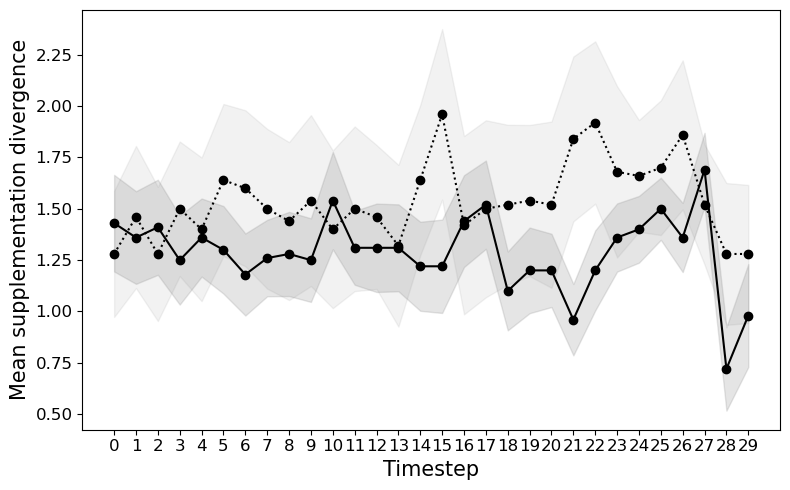

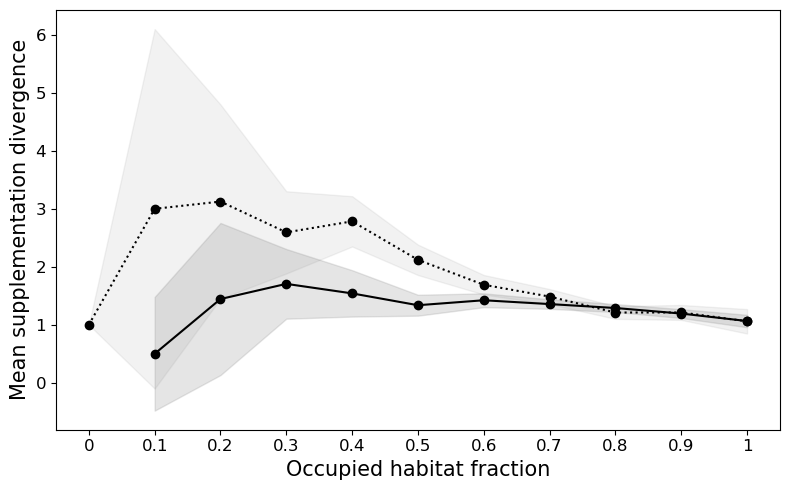

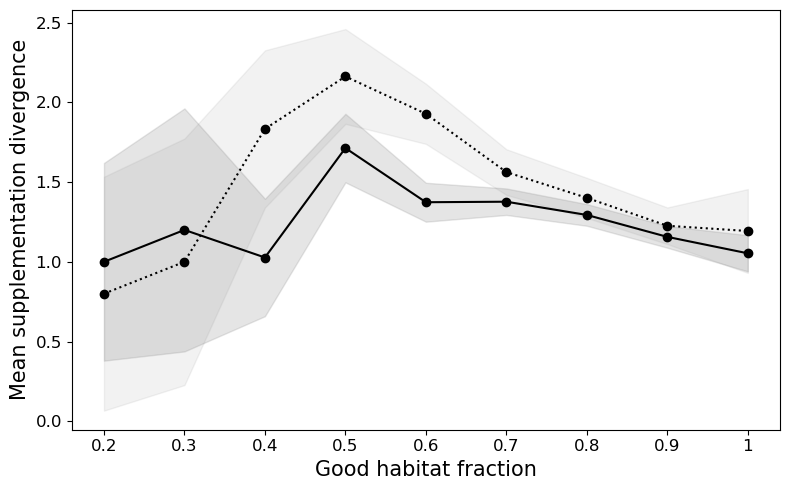

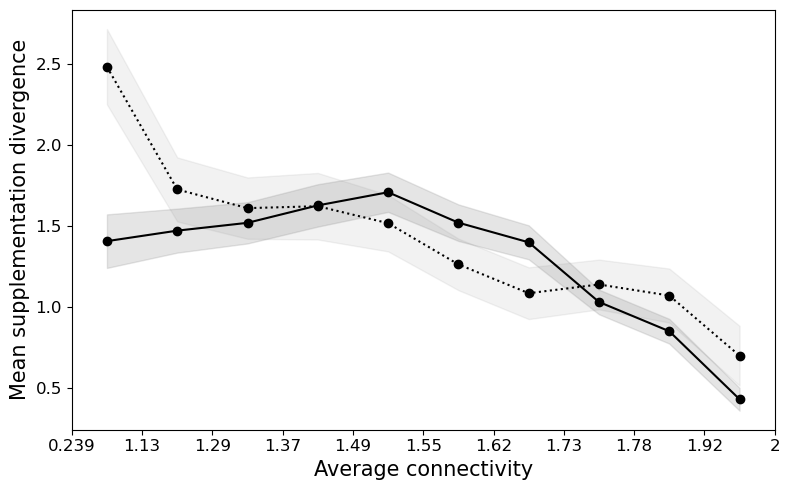

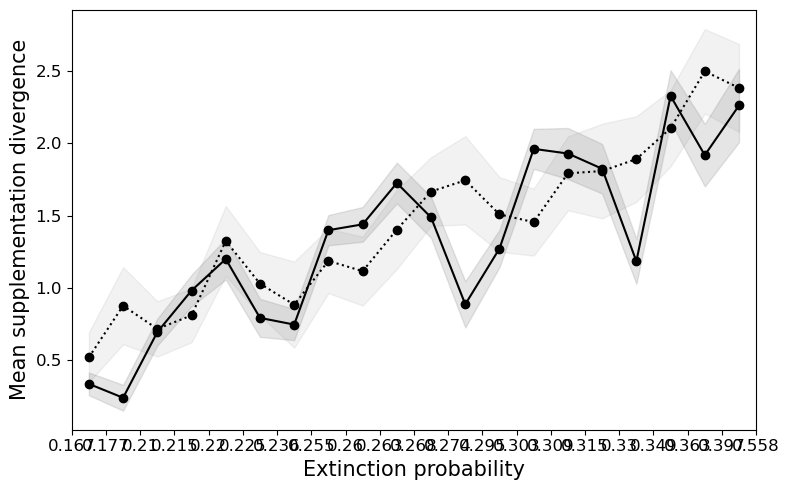

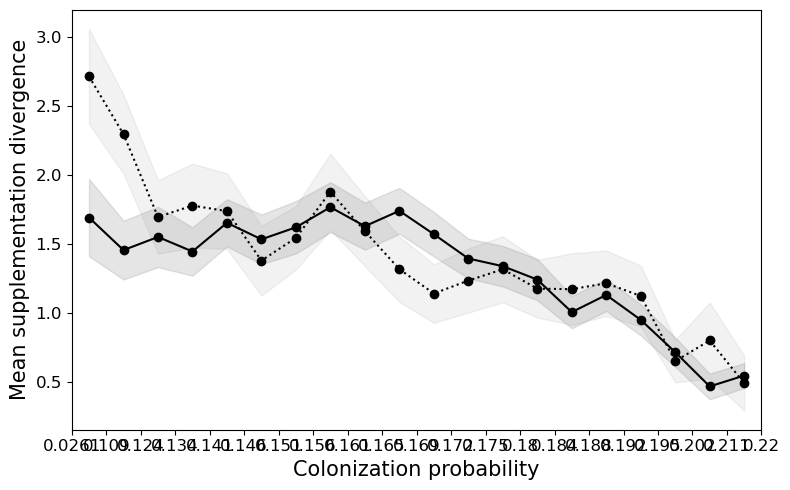

In [49]:
# same for supplementation 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

###################################################
envid = 20 # 18= n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
legend_on = 0 # if 1, show legend/title; if 0, hide both.
# only use 20. we specifically got more samples for step-scale analysis.
###################################################

# Heuristic play data
heur_playdf, _ = call_in_heuristic_data(envid=envid, with_valdiff=True, merge=True)
patchnum = heur_playdf['observations'][0].shape[0]  # assuming all observations have the same shape
print(patchnum)

# Human play data
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df(playdf, patchnum):
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t = np.array([s[0, -1] for s in playdf['observations']])
    occfrac = playdf['occfraction_per_episode']
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']

    # Supplementation action distance relative to RL action (first half of action vector).
    sadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:, patchnum:]).sum(axis=1)

    return pd.DataFrame({
        'delV': delV,
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'sadist': sadist,
    })

heur_df = build_df(heur_playdf, patchnum)
human_df = build_df(human_playdf, patchnum)

# Plot mean restoration distance against each state variable in separate figures.
plot_specs = [
    ('t', 20, 'Timestep', 'Restoration action distance vs\n Timestep'),
    ('occfrac', 3, 'Occupied habitat fraction', 'Restoration action distance vs\n Occupied Habitat Fraction'),
    ('goodhfrac', 3, 'Good habitat fraction', 'Restoration action distance vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Restoration action distance vs\n Average Connectivity'),
    ('eprob', 20, 'Extinction probability', 'Restoration action distance vs\n Extinction Probability'),
    ('cprob', 20, 'Colonization probability', 'Restoration action distance vs\n Colonization Probability'),
]

discrete_cols = {'t', 'occfrac', 'goodhfrac'}

heur_line_color = 'black'
heur_ci_color = 'gray'
heur_line_style = '-'
human_line_color = 'black'
human_ci_color = 'gray'
human_line_style = ':'

for col, n_bins, xlabel, title in plot_specs:
    hx = pd.to_numeric(heur_df[col], errors='coerce')
    hy = pd.to_numeric(heur_df['sadist'], errors='coerce')
    hv = hx.notna() & hy.notna()
    hx = hx[hv]
    hy = hy[hv]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['sadist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    plt.figure(figsize=(8, 5))

    if col in discrete_cols:
        # Equal spacing by category index, shared between heuristic and human.
        all_vals = np.sort(np.unique(np.concatenate([hx.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h_grouped = hy.groupby(hx).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h_means = h_grouped['mean'].to_numpy(dtype=float)
        h_stds = h_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h_counts = h_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        h_ci95 = 1.96 * h_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        plt.plot(x_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        plt.fill_between(x_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        plt.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        plt.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_pos, [f'{v:g}' for v in all_vals], fontsize=12)
        plt.xlabel(f'{xlabel}', fontsize=15)
        plt.yticks(fontsize=12)
    else:
        # Equal spacing by bin index with shared quantile edges across both datasets.
        all_x = pd.concat([hx, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h_ids = pd.cut(hx, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h_grouped = hy.groupby(h_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h_means = np.full(n_actual_bins, np.nan, dtype=float)
        h_stds = np.full(n_actual_bins, np.nan, dtype=float)
        h_counts = np.zeros(n_actual_bins, dtype=float)

        for idx, row in h_grouped.iterrows():
            if pd.notna(idx):
                i = int(idx)
                h_means[i] = float(row['mean'])
                h_stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
                h_counts[i] = float(row['count'])

        u_means = np.full(n_actual_bins, np.nan, dtype=float)
        u_stds = np.full(n_actual_bins, np.nan, dtype=float)
        u_counts = np.zeros(n_actual_bins, dtype=float)

        for idx, row in u_grouped.iterrows():
            if pd.notna(idx):
                i = int(idx)
                u_means[i] = float(row['mean'])
                u_stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
                u_counts[i] = float(row['count'])

        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        h_ci95 = 1.96 * h_sem
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        plt.plot(x_mean_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        plt.fill_between(x_mean_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        plt.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        plt.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_edge_pos, edge_labels, fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlim(0, n_actual_bins)
        plt.xlabel(f'{xlabel}', fontsize=15)

    plt.ylabel('Mean supplementation divergence', fontsize=15)
    if legend_on == 1:
        plt.title(title, fontsize=15)
        plt.legend()
    plt.xticks(fontsize=12)
    plt.tight_layout()
    plt.show()


10


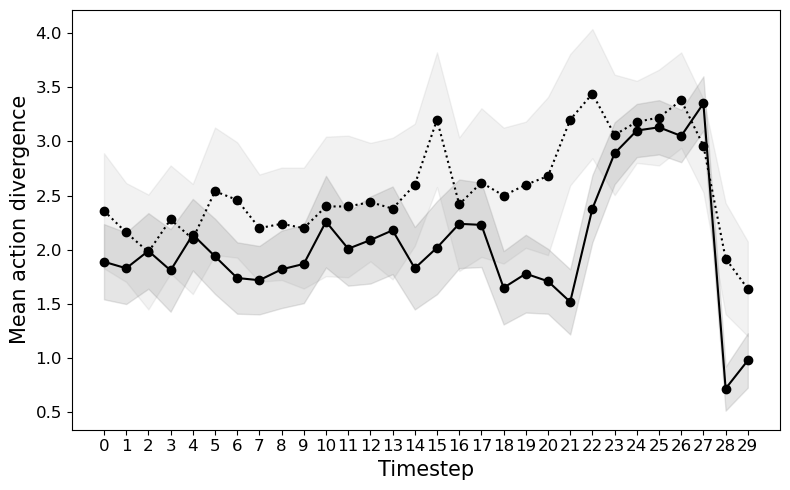

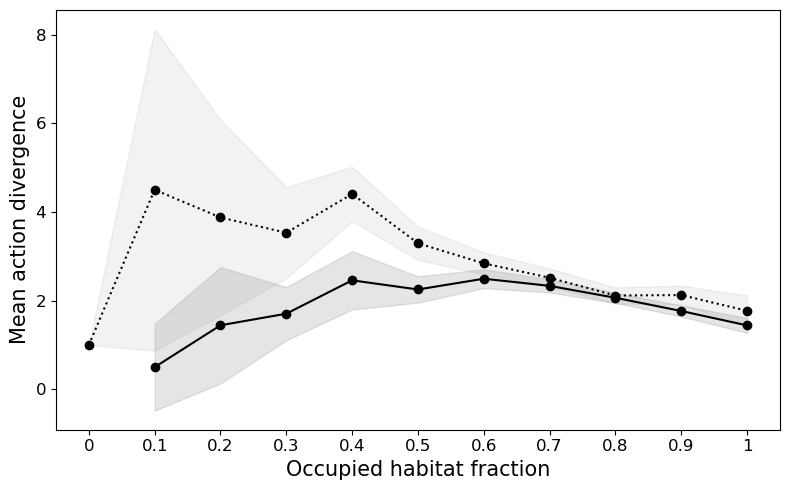

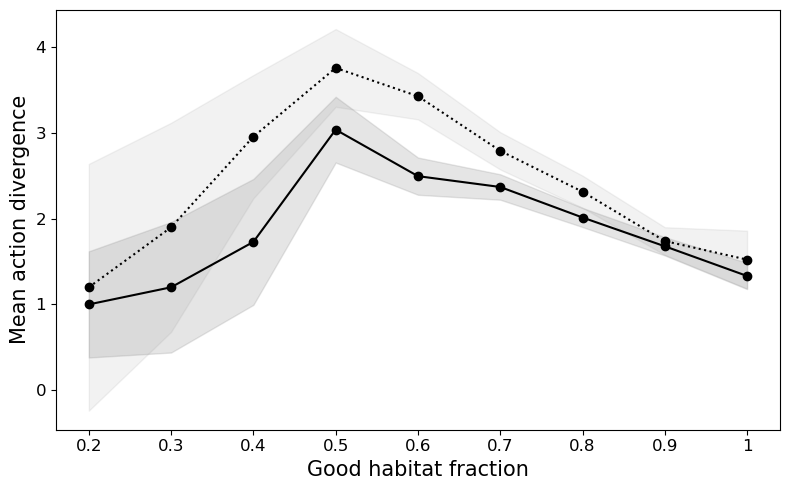

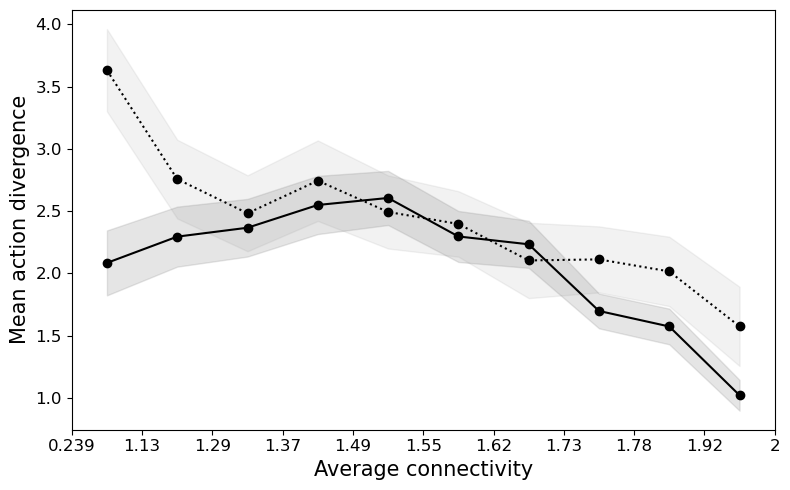

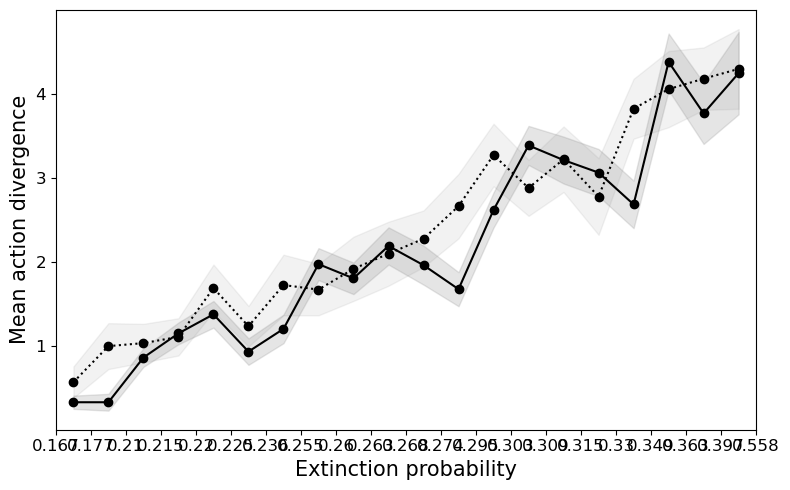

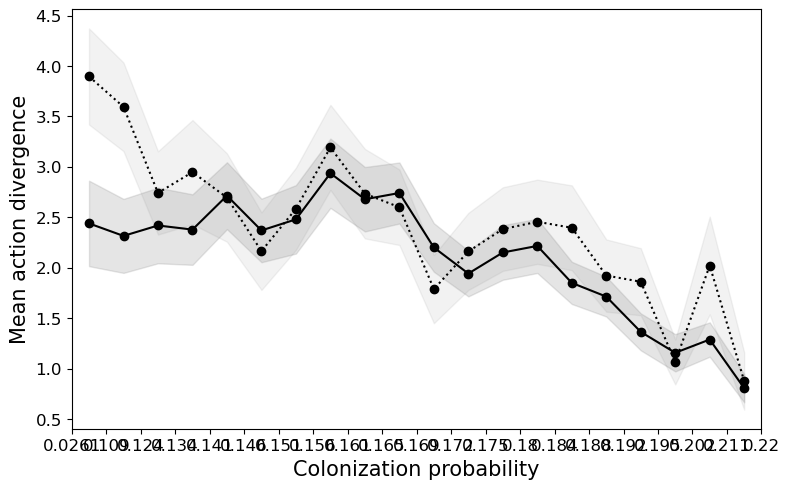

In [55]:
# for both actions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

###################################################
envid = 20 # 18= n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
legend_on = 0 # if 1, show legend/title; if 0, hide both.
# only use 20. we specifically got more samples for step-scale analysis.
###################################################

# Heuristic play data
heur_playdf, _ = call_in_heuristic_data(envid=envid, with_valdiff=True, merge=True)
patchnum = heur_playdf['observations'][0].shape[0]  # assuming all observations have the same shape
print(patchnum)

# Human play data
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df(playdf, patchnum):
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t = np.array([s[0, -1] for s in playdf['observations']])
    occfrac = playdf['occfraction_per_episode']
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']

    # Supplementation action distance relative to RL action (first half of action vector).
    adist = playdf['L1_a_dist_RLsampled_a']

    return pd.DataFrame({
        'delV': delV,
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'adist': adist,
    })

heur_df = build_df(heur_playdf, patchnum)
human_df = build_df(human_playdf, patchnum)

# Plot mean restoration distance against each state variable in separate figures.
plot_specs = [
    ('t', 20, 'Timestep', 'Restoration action distance vs\n Timestep'),
    ('occfrac', 3, 'Occupied habitat fraction', 'Restoration action distance vs\n Occupied Habitat Fraction'),
    ('goodhfrac', 3, 'Good habitat fraction', 'Restoration action distance vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Restoration action distance vs\n Average Connectivity'),
    ('eprob', 20, 'Extinction probability', 'Restoration action distance vs\n Extinction Probability'),
    ('cprob', 20, 'Colonization probability', 'Restoration action distance vs\n Colonization Probability'),
]

discrete_cols = {'t', 'occfrac', 'goodhfrac'}

heur_line_color = 'black'
heur_ci_color = 'gray'
heur_line_style = '-'
human_line_color = 'black'
human_ci_color = 'gray'
human_line_style = ':'

for col, n_bins, xlabel, title in plot_specs:
    hx = pd.to_numeric(heur_df[col], errors='coerce')
    hy = pd.to_numeric(heur_df['adist'], errors='coerce')
    hv = hx.notna() & hy.notna()
    hx = hx[hv]
    hy = hy[hv]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['adist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    plt.figure(figsize=(8, 5))

    if col in discrete_cols:
        # Equal spacing by category index, shared between heuristic and human.
        all_vals = np.sort(np.unique(np.concatenate([hx.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h_grouped = hy.groupby(hx).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h_means = h_grouped['mean'].to_numpy(dtype=float)
        h_stds = h_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h_counts = h_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        h_ci95 = 1.96 * h_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        plt.plot(x_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        plt.fill_between(x_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        plt.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        plt.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_pos, [f'{v:g}' for v in all_vals], fontsize=12)
        plt.xlabel(f'{xlabel}', fontsize=15)
        plt.yticks(fontsize=12)
    else:
        # Equal spacing by bin index with shared quantile edges across both datasets.
        all_x = pd.concat([hx, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h_ids = pd.cut(hx, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h_grouped = hy.groupby(h_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h_means = np.full(n_actual_bins, np.nan, dtype=float)
        h_stds = np.full(n_actual_bins, np.nan, dtype=float)
        h_counts = np.zeros(n_actual_bins, dtype=float)

        for idx, row in h_grouped.iterrows():
            if pd.notna(idx):
                i = int(idx)
                h_means[i] = float(row['mean'])
                h_stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
                h_counts[i] = float(row['count'])

        u_means = np.full(n_actual_bins, np.nan, dtype=float)
        u_stds = np.full(n_actual_bins, np.nan, dtype=float)
        u_counts = np.zeros(n_actual_bins, dtype=float)

        for idx, row in u_grouped.iterrows():
            if pd.notna(idx):
                i = int(idx)
                u_means[i] = float(row['mean'])
                u_stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
                u_counts[i] = float(row['count'])

        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        h_ci95 = 1.96 * h_sem
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        plt.plot(x_mean_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        plt.fill_between(x_mean_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        plt.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        plt.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_edge_pos, edge_labels, fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlim(0, n_actual_bins)
        plt.xlabel(f'{xlabel}', fontsize=15)

    plt.ylabel('Mean action divergence', fontsize=15)
    if legend_on == 1:
        plt.title(title, fontsize=15)
        plt.legend()
    plt.xticks(fontsize=12)
    plt.tight_layout()
    plt.show()


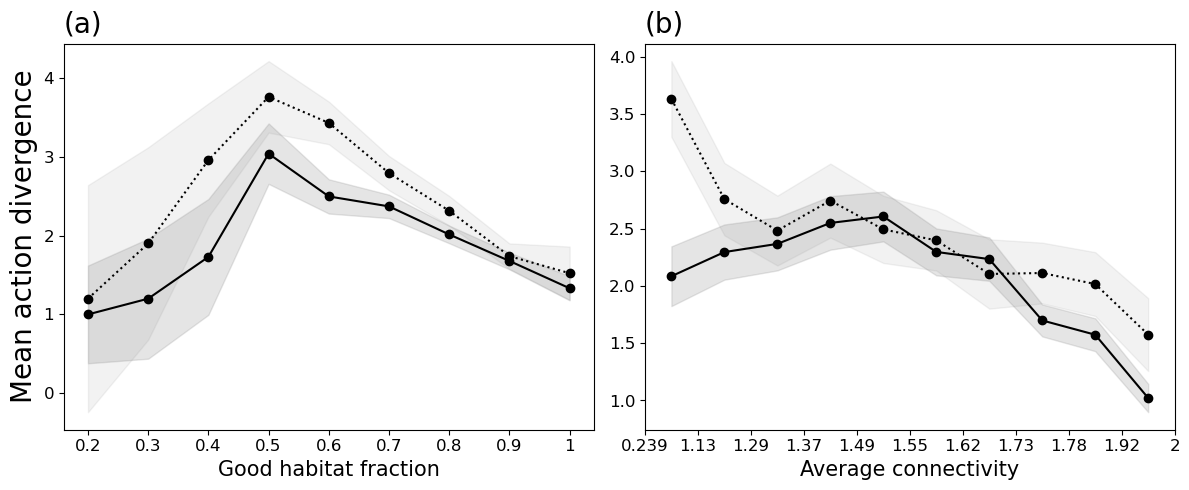

In [62]:
# NEW CELL: 1x2 subplot for both actions (adist)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

envid = 20
legend_on = 0

heur_playdf, _ = call_in_heuristic_data(envid=envid, with_valdiff=True, merge=True)
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df_both(playdf):
    return pd.DataFrame({
        'goodhfrac': pd.to_numeric(playdf['goodHfraction_per_episode'], errors='coerce'),
        'avgconn': pd.to_numeric(playdf['avgconnectivity_per_episode'], errors='coerce'),
        'adist': pd.to_numeric(playdf['L1_a_dist_RLsampled_a'], errors='coerce'),
    })

heur_df = build_df_both(heur_playdf)
human_df = build_df_both(human_playdf)

plot_specs = [
    ('goodhfrac', 3, 'Good habitat fraction', 'Mean action divergence vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Mean action divergence vs\n Average Connectivity'),
]

discrete_cols = {'goodhfrac'}

heur_line_color = 'black'
human_line_color = 'black'
heur_line_style = '-'
human_line_style = ':'
heur_ci_color = 'gray'
human_ci_color = 'gray'

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
letters = 'abcdefghijklmnopqrstuvwxyz'

for i, (ax, (col, n_bins, xlabel, title)) in enumerate(zip(axs, plot_specs)):
    hx = pd.to_numeric(heur_df[col], errors='coerce')
    hy = pd.to_numeric(heur_df['adist'], errors='coerce')
    hv = hx.notna() & hy.notna()
    hx = hx[hv]
    hy = hy[hv]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['adist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    if col in discrete_cols:
        all_vals = np.sort(np.unique(np.concatenate([hx.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h_grouped = hy.groupby(hx).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h_means = h_grouped['mean'].to_numpy(dtype=float)
        h_stds = h_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h_counts = h_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        h_ci95 = 1.96 * h_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)

        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        ax.plot(x_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        ax.fill_between(x_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        ax.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        ax.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        ax.set_xticks(x_pos, [f'{v:g}' for v in all_vals], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xlabel(xlabel, fontsize=15)
    else:
        all_x = pd.concat([hx, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h_ids = pd.cut(hx, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h_grouped = hy.groupby(h_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h_means = np.full(n_actual_bins, np.nan, dtype=float)
        h_stds = np.full(n_actual_bins, np.nan, dtype=float)
        h_counts = np.zeros(n_actual_bins, dtype=float)
        for idx, row in h_grouped.iterrows():
            if pd.notna(idx):
                i_bin = int(idx)
                h_means[i_bin] = float(row['mean'])
                h_stds[i_bin] = 0.0 if pd.isna(row['std']) else float(row['std'])
                h_counts[i_bin] = float(row['count'])

        u_means = np.full(n_actual_bins, np.nan, dtype=float)
        u_stds = np.full(n_actual_bins, np.nan, dtype=float)
        u_counts = np.zeros(n_actual_bins, dtype=float)
        for idx, row in u_grouped.iterrows():
            if pd.notna(idx):
                i_bin = int(idx)
                u_means[i_bin] = float(row['mean'])
                u_stds[i_bin] = 0.0 if pd.isna(row['std']) else float(row['std'])
                u_counts[i_bin] = float(row['count'])

        h_sem = np.divide(h_stds, np.sqrt(h_counts), out=np.full_like(h_stds, np.nan), where=h_counts > 0)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        h_ci95 = 1.96 * h_sem
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        ax.plot(x_mean_pos, h_means, marker='o', linestyle=heur_line_style, color=heur_line_color, label='Heuristic mean')
        ax.fill_between(x_mean_pos, h_means - h_ci95, h_means + h_ci95, color=heur_ci_color, alpha=0.20, label='Heuristic 95% CI')
        ax.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        ax.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        ax.set_xticks(x_edge_pos, edge_labels, fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xlim(0, n_actual_bins)
        ax.set_xlabel(xlabel, fontsize=15)

    ax.text(0.0, 1.03, f"({letters[i]})", transform=ax.transAxes, fontsize=20)

    if legend_on == 1:
        ax.set_title(title, fontsize=15)

axs[0].set_ylabel('Mean action divergence', fontsize=20)
if legend_on == 1:
    axs[0].legend()

plt.tight_layout()
plt.show()

# Figure 3. bar plot

supplementation partial effect residual correlations for env 18: -0.0819, significant: True
restoration partial effect residual correlations for env 18: 0.0131, significant: False


supplementation partial effect residual correlations for env 20: -0.1606, significant: True
restoration partial effect residual correlations for env 20: -0.1791, significant: True


supplementation partial effect residual correlations for env 21: -0.1599, significant: True
restoration partial effect residual correlations for env 21: -0.4074, significant: True


supplementation partial effect residual correlations for env 22: -0.2027, significant: True
restoration partial effect residual correlations for env 22: -0.2262, significant: True


supplementation partial effect residual correlations for env 23: -0.1602, significant: True
restoration partial effect residual correlations for env 23: -0.1601, significant: True




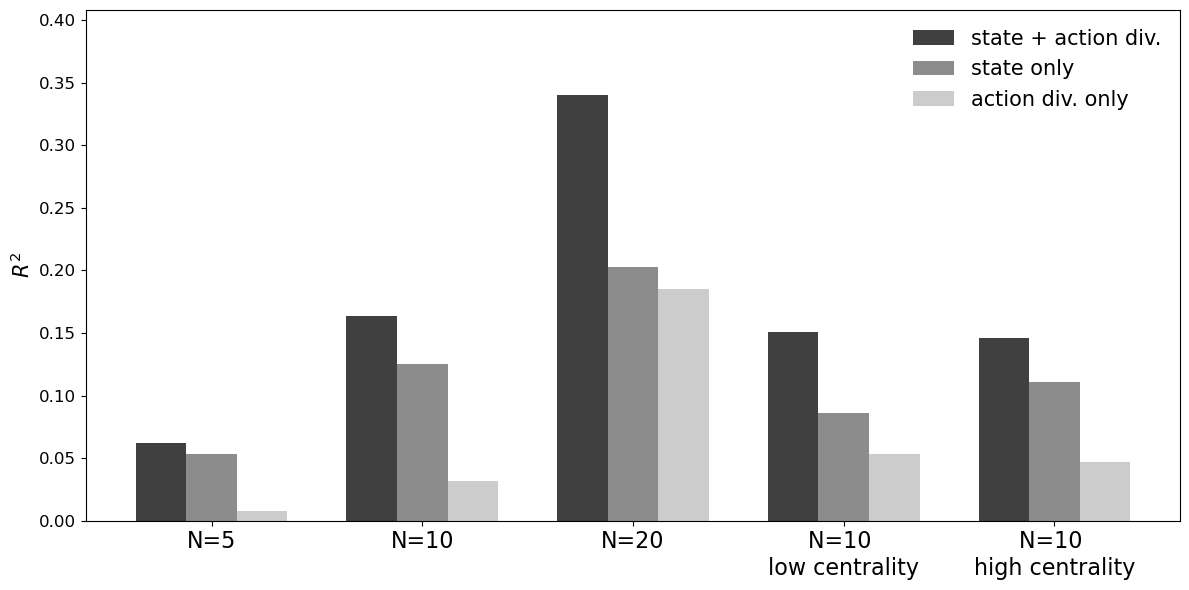

In [97]:
from call_in_data import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
###################################################
envid = 20 # 18= n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
use_connectivity_weighted_action = 0 # 0=no, 1=connectivity weighted, 2=inv connectivity weighted
heur = 1 # if 1, use heuristic data; if 0, use human data.
###################################################
R2onlystate = []
R2onlyaction = []
R2full = []
rresidcorrs = []
rresidcorrs_significant = []
sresidcorrs = []
sresidcorrs_significant = []

for envid in [18,20,21,22,23]:
    if heur == 1:
        playdf,_ = call_in_heuristic_data(envid=envid, with_valdiff=True, merge=True)
    else:
        playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)
    patchnum = playdf['observations'][0].shape[0]  # assuming all observations have the same shape
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t = np.array([s[0,-1] for s in playdf['observations']])
    connectivity = np.array([s[:,2] for s in playdf['observations']])
    invconnectivity = 1/(connectivity+1e-5)  # add small constant to avoid division by zero
    occfrac = playdf['occfraction_per_episode']
    adist = playdf['L1_a_dist_RLsampled_a']
    connectivity_expanded = np.concatenate([connectivity, connectivity], axis=1)
    invconnectivity_expanded = np.concatenate([invconnectivity, invconnectivity], axis=1)
    connecadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))*connectivity_expanded).sum(axis=1)  # connectivity weighted L1 distance
    invconnecadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))*invconnectivity_expanded).sum(axis=1)  # inverse connectivity weighted L1 distance
    radist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,:patchnum]).sum(axis=1)
    sadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,patchnum:]).sum(axis=1)
    connecradist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,:patchnum]*connectivity).sum(axis=1)
    invconnecradist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,:patchnum]*invconnectivity).sum(axis=1)
    connecsadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,patchnum:]*connectivity).sum(axis=1)
    invconnecsadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,patchnum:]*invconnectivity).sum(axis=1)
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']
    restorefrac = playdf['restore_fraction_per_episode']
    suppfrac = playdf['supp_fraction_per_episode']

    import statsmodels.api as sm
    import pandas as pd
    from sklearn.preprocessing import StandardScaler

    df = pd.DataFrame({
        'delV': delV,
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'radist': radist,
        'sadist': sadist,
        'connecradist': connecradist,
        'invconnecradist': invconnecradist,
        'connecsadist': connecsadist,
        'invconnecsadist': invconnecsadist,
    })


    # 
    # standardize
    cols = ['t','occfrac','goodhfrac','avgconn','eprob','radist','sadist']
    state_cols = ['t','occfrac','goodhfrac','avgconn','eprob']
    if use_connectivity_weighted_action == 0:
        adist_cols = ['radist','sadist']
    elif use_connectivity_weighted_action == 1:
        adist_cols = ['connecradist','connecsadist']
    elif use_connectivity_weighted_action == 2:
        adist_cols = ['invconnecradist','invconnecsadist']
    df_std = df.copy()
    df_std[cols] = StandardScaler().fit_transform(df[cols])
    # Model A: state only
    Xa = sm.add_constant(df_std[state_cols])
    modelA = sm.OLS(df_std['delV'], Xa).fit()
    R2onlystate.append(modelA.rsquared)
    # Model B: action distance only
    Xb = sm.add_constant(df_std[adist_cols])
    modelB = sm.OLS(df_std['delV'], Xb).fit()
    R2onlyaction.append(modelB.rsquared)
    # Model C: full model
    Xc = sm.add_constant(df_std[state_cols + adist_cols])
    modelC = sm.OLS(df_std['delV'], Xc).fit()
    R2full.append(modelC.rsquared)

    # check partial effect of action distance by looking at residuals
    resid_y = modelA.resid
    Xa_dist = sm.add_constant(df_std[state_cols])
    model_dist = sm.OLS(df_std[adist_cols[0]], Xa_dist).fit()
    model_dist2 = sm.OLS(df_std[adist_cols[1]], Xa_dist).fit()
    resid_x = model_dist.resid
    resid_x2 = model_dist2.resid

    residcor, resid_p = pearsonr(resid_x, resid_y)
    residcor2, resid_p2 = pearsonr(resid_x2, resid_y)
    rresidcorrs.append(residcor)
    sresidcorrs.append(residcor2)
    rresidcorrs_significant.append(resid_p < 0.05)
    sresidcorrs_significant.append(resid_p2 < 0.05)

for i, envid in enumerate([18,20,21,22,23]):
    print(f'supplementation partial effect residual correlations for env {envid}: {sresidcorrs[i]:.4f}, significant: {sresidcorrs_significant[i]}')
    print(f'restoration partial effect residual correlations for env {envid}: {rresidcorrs[i]:.4f}, significant: {rresidcorrs_significant[i]}')
    print(f'\n')

# grouped barplot, group=envi, within group: R2full, R2onlystate, R2onlyaction (in that order), no colors, only grey scale. use group name for group xlabel
group_name = {
    18: 'N=5',
    20: 'N=10',
    21: 'N=20',
    22: 'N=10 \nlow centrality',
    23: 'N=10 \nhigh centrality',
}

env_order = [18, 20, 21, 22, 23]
labels = [group_name[e] for e in env_order]
x = np.arange(len(env_order), dtype=float)
width = 0.24

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, R2full, width, color='0.25', label='state + action div.')
ax.bar(x, R2onlystate, width, color='0.55', label='state only')
ax.bar(x + width, R2onlyaction, width, color='0.80', label='action div. only')

ax.set_xticks(x, labels, fontsize=16)
ax.set_ylabel(r'$R^2$', fontsize=15)
ax.set_ylim(0, max(max(R2full), max(R2onlystate), max(R2onlyaction)) * 1.20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=12)
# xlabel size larger 
ax.legend(frameon=False, fontsize=15)

plt.tight_layout()
plt.show()

In [93]:
np.round(np.array(R2onlyaction)/np.array(R2onlystate), 2)


array([0.15, 0.25, 0.91, 0.62, 0.42])

n=18, t-statistic=-2.17, p-value=0.0301


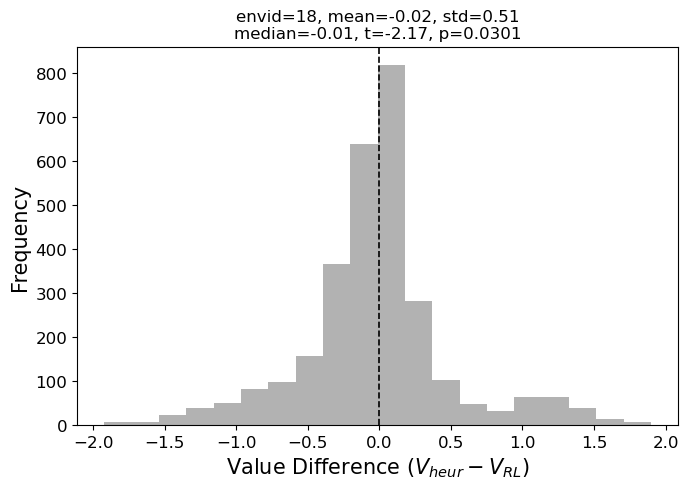

n=20, t-statistic=-19.83, p-value=0.0000


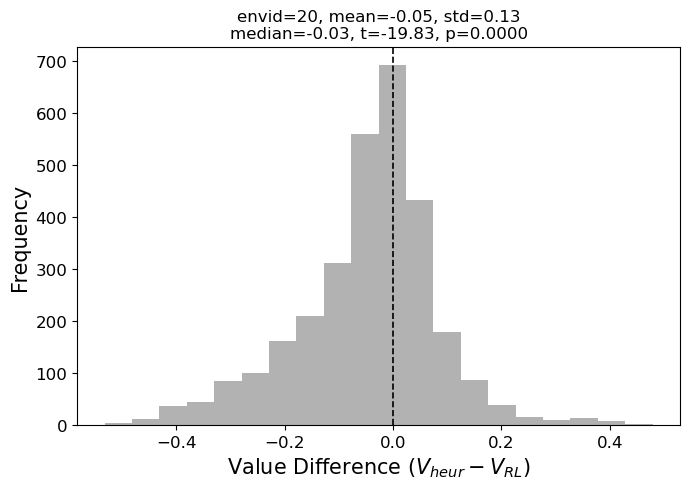

n=21, t-statistic=-23.59, p-value=0.0000


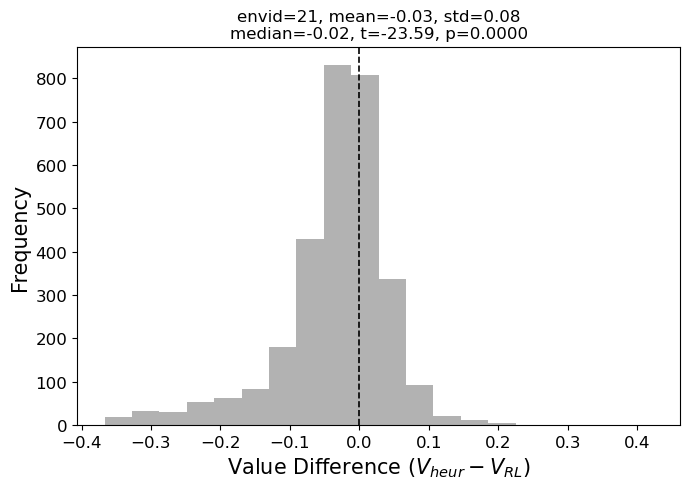

n=22, t-statistic=-19.20, p-value=0.0000


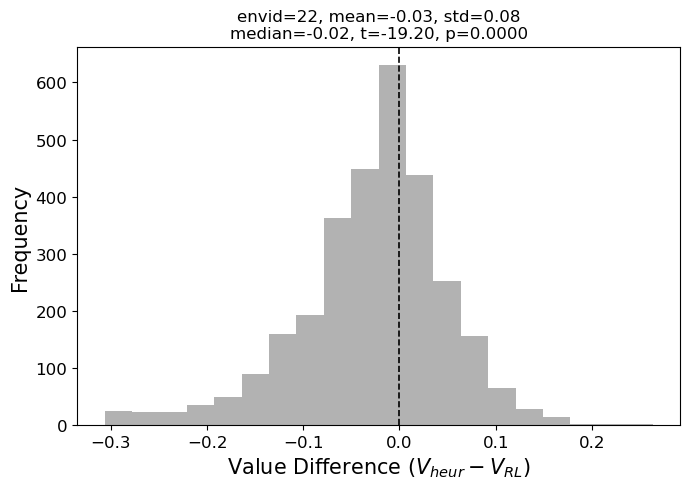

n=23, t-statistic=-17.95, p-value=0.0000


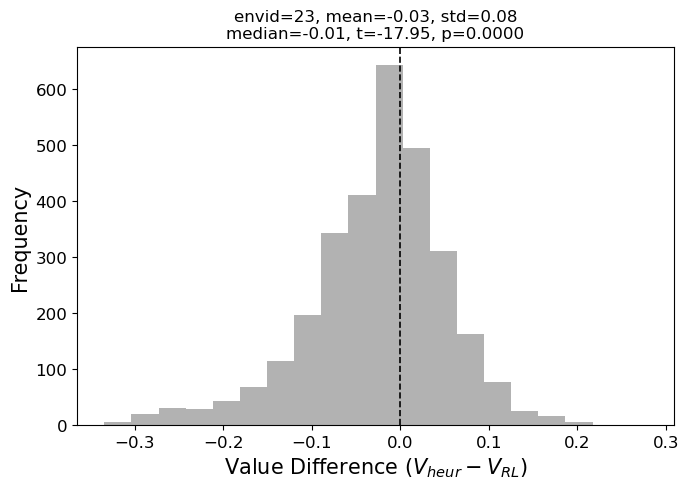

In [88]:
# histogram of value differences
from call_in_data import *
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
notitle = False
envids = [18, 20, 21, 22, 23]

for n in envids:
    playdf, filenames = call_in_heuristic_data(envid=n, with_valdiff=True, merge=True)
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t_stat, p_value = stats.ttest_1samp(delV, 0)
    print(f'n={n}, t-statistic={t_stat:.2f}, p-value={p_value:.4f}')

    plt.figure(figsize=(7, 5))
    plt.hist(delV, bins=20, color='grey', alpha=0.60)
    plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
    if not notitle:
        plt.title(f'envid={n}, mean={np.mean(delV):.2f}, std={np.std(delV):.2f}\nmedian={np.median(delV):.2f}, t={t_stat:.2f}, p={p_value:.4f}')
    plt.xlabel(r'Value Difference ($V_{heur} - V_{RL}$)', fontsize=15)
    plt.ylabel('Frequency', fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()